# Argon MD with PhysNet: `xnn` NPT density + lock-step NVE against the original

The sharpest test of a potential is *simulation*. This notebook trains the
`xnn` PhysNet on the Argon data and

* runs **NPT MD** at 85 K / 1 bar to recover the liquid-argon **density**
  (~1.41 g/cm³) through the standard xnn ASE deployment, and
* validates the MD *forces* against the **original TF1 PhysNet** in a
  **lock-step NVE run**: both codes propagate the *same* trajectory from the
  same initial conditions, and we track how the two force engines agree
  step by step.

(The original TF implementation exposes no stress, so the NPT track is
xnn-only; the lock-step NVE comparison plays the role of the "same potential,
two MD engines" track of the other model series.)

## 0. Setup

In [1]:
# silence the expected warnings / TF chatter
import logging, os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")

import subprocess, sys, tempfile
import numpy as np

# ---- the original TF1 PhysNet (cloned on demand) ----
UPSTREAM = os.environ.get("PHYSNET_UPSTREAM_PATH",
                          os.path.join(tempfile.gettempdir(), "physnet-upstream"))
if not os.path.isdir(UPSTREAM):
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/MMunibas/PhysNet", UPSTREAM], check=True)

import tensorflow.compat.v1 as tf
tf.disable_eager_execution()
tf.get_logger().setLevel("ERROR")
sys.modules["tensorflow"] = tf          # upstream modules do `import tensorflow as tf`
# upstream applies dropout with keep_prob = 1.0 (identity); its float32
# placeholder trips TF2's dtype check in float64 graphs
tf.nn.dropout = lambda x, keep_prob=None, **kw: x

sys.path.insert(0, UPSTREAM)
import neural_network.NeuralNetwork as _nnmod
from neural_network.NeuralNetwork import NeuralNetwork

import time
import torch
import matplotlib.pyplot as plt
import ase.io
import ase.units as u

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
import xnn
DATA = "../../../datasets/argon_md"
print("xnn:", xnn.__version__, "| tensorflow:", tf.__version__, "| torch:", torch.__version__)

xnn: 0.1.0 | tensorflow: 2.21.0 | torch: 2.12.1+cpu


## 1. Data and training (same recipe as notebook 02)

In [2]:
from xnn.common.data import AtomicDataset, load_dataset
from xnn.common.config import from_dict
from xnn.common.models import build_model, ForceStressOutput
from xnn.common.train import Trainer
from torch.utils.data import Subset

SR_CUT, LR_CUT = 6.0, 9.0
F_DIM, K, NB, NRA, NRI, NRO = 64, 32, 3, 2, 3, 1
EW, FW, LR, BS, EPOCHS = 1.0, 100.0, 1e-3, 10, 40

E0 = {18: 0.0}   # argon isolated-atom reference energy
train_structs = load_dataset("argon_md", split="train")
ds_all = AtomicDataset(train_structs, LR_CUT)
train_structs = [s for i, s in enumerate(train_structs) if ds_all[i].num_edges > 0]
xnn_train = AtomicDataset(train_structs, LR_CUT)
g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(train_structs), generator=g).tolist()
n_val = max(1, int(0.1 * len(train_structs)))
val_idx, train_idx = perm[:n_val], perm[n_val:]

core = from_dict({
    "model": {"name": "physnet", "cutoff": SR_CUT, "n_features": F_DIM,
              "n_rbf": K, "n_interactions": NB, "lr_cutoff": LR_CUT,
              "num_residual_atomic": NRA, "num_residual_interaction": NRI,
              "num_residual_output": NRO, "species": [18],
              "atomic_energies": [E0[18]]},
    "data": {"batch_size": BS},
    "optim": {"lr": LR, "epochs": EPOCHS, "energy_weight": EW, "force_weight": FW,
              "scheduler": "plateau"},
    "device": "cpu", "seed": 0, "output_dir": "runs/argon_md",
})
t0 = time.time()
trainer = Trainer(core, Subset(xnn_train, train_idx), Subset(xnn_train, val_idx))
trainer.fit()
print(f"xnn PhysNet trained {EPOCHS} epochs in {time.time()-t0:.0f} s")
model = trainer.model.model

epoch    0 | train loss 4.7140e-01 | val loss 2.5822e-01


epoch    1 | train loss 1.8560e-01 | val loss 3.7692e-02


epoch    2 | train loss 6.3110e-02 | val loss 3.5621e-02


epoch    3 | train loss 5.0543e-02 | val loss 2.4506e-02


epoch    4 | train loss 4.7849e-02 | val loss 1.9057e-02


...

epoch   35 | train loss 8.5183e-04 | val loss 6.1312e-04


epoch   36 | train loss 1.1504e-03 | val loss 4.3789e-04


epoch   37 | train loss 9.2245e-04 | val loss 3.9981e-04


epoch   38 | train loss 8.0201e-04 | val loss 5.2919e-04


epoch   39 | train loss 8.6198e-04 | val loss 4.3481e-04
xnn PhysNet trained 40 epochs in 648 s


## 2. NPT density: `xnn` PhysNet through ASE (float64)

In [3]:
torch.set_default_dtype(torch.float64)
from ase import Atoms
from ase.md.nptberendsen import NPTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from xnn.common.deploy import XNNCalculator

model64 = model.double().eval()
md_model = ForceStressOutput(model64, compute_forces=True, compute_stress=True)

T_K, P_BAR, DT = 85.0, 1.0, 5 * u.fs
N_EQUIL, N_PROD = 300, 700
AMU_A3_TO_G_CM3 = 1.6605390666
RHO_EXP = 1.41
a0 = train_structs[0]

def density(atoms):
    return atoms.get_masses().sum() / atoms.get_volume() * AMU_A3_TO_G_CM3

at = Atoms(numbers=a0["atomic_numbers"], positions=a0["pos"], cell=a0["cell"], pbc=True)
at.calc = XNNCalculator(md_model, cutoff=model64.cutoff)
MaxwellBoltzmannDistribution(at, temperature_K=T_K, rng=np.random.default_rng(0)); Stationary(at)
dyn = NPTBerendsen(at, timestep=DT, temperature_K=T_K, pressure_au=P_BAR * u.bar,
                   taut=100 * u.fs, taup=1000 * u.fs, compressibility_au=2e-4 / u.bar)
rho = np.empty(N_EQUIL + N_PROD)
t0 = time.time()
for k in range(N_EQUIL + N_PROD):
    dyn.run(1); rho[k] = density(at)
print(f"NPT: {N_EQUIL+N_PROD} steps in {time.time()-t0:.0f} s | "
      f"rho_eq = {rho[N_EQUIL:].mean():.4f} ± {rho[N_EQUIL:].std():.3f} g/cm3 "
      f"(exp ~{RHO_EXP})")

NPT: 1000 steps in 214 s | rho_eq = 1.4122 ± 0.007 g/cm3 (exp ~1.41)


## 3. Lock-step NVE: the trained xnn weights through both codes

The trained weights are transplanted **into the original TF graph** (the
reverse of the usual direction), an ASE calculator is wrapped around the TF1
session, and both engines propagate velocity-Verlet NVE from identical initial
conditions. With the same potential, positions/energies should track each other
at float32 round-off (slow chaotic divergence is expected in any two float32
force engines).

In [4]:
from xnn.common.data import build_neighbor_list
from ase.calculators.calculator import Calculator, all_changes
from ase.md.verlet import VelocityVerlet

# --- TF graph (float32) + reverse transplant of the trained torch weights ---
tf.reset_default_graph()
tf_nn = NeuralNetwork(F=F_DIM, K=K, sr_cut=SR_CUT, lr_cut=LR_CUT, num_blocks=NB,
                      num_residual_atomic=NRA, num_residual_interaction=NRI,
                      num_residual_output=NRO, use_electrostatic=True,
                      use_dispersion=True, scope="nn", seed=0)
ph = {"Z": tf.placeholder(tf.int32, [None]), "R": tf.placeholder(tf.float32, [None, 3]),
      "idx_i": tf.placeholder(tf.int32, [None]), "idx_j": tf.placeholder(tf.int32, [None]),
      "offsets": tf.placeholder(tf.float32, [None, 3])}
E_op = tf_nn.energy(ph["Z"], ph["R"], ph["idx_i"], ph["idx_j"], offsets=ph["offsets"])
F_op = -tf.gradients(tf.reduce_sum(E_op), ph["R"])[0]
sess = tf.Session()
sess.run(tf.global_variables_initializer())

def torch_to_tf(x, num_blocks, scope="nn"):
    """Assign every xnn PhysNet weight into the TF1 graph."""
    named = dict(x.named_parameters()); named.update(dict(x.named_buffers()))
    def put(vname, key):
        v = [v for v in tf.global_variables() if v.name == f"{scope}/{vname}:0"][0]
        sess.run(v.assign(named[key].detach().cpu().numpy()))
    put("embeddings", "embeddings")
    put("rbf_layer/centers", "rbf_layer.centers"); put("rbf_layer/widths", "rbf_layer.widths")
    for t in ["Eshift", "Escale", "Qshift", "Qscale"]: put(t, t)
    for t in ["s6", "s8", "a1", "a2"]: put(t, f"_{t}")
    for b in range(num_blocks):
        sc, pb = f"interaction_block{b}", f"interaction_blocks.{b}"
        put(f"{sc}/interaction_layer/k2f/W", f"{pb}.interaction.k2f.weight")
        for nm in ["dense_i", "dense_j", "dense"]:
            put(f"{sc}/interaction_layer/{nm}/W", f"{pb}.interaction.{nm}.weight")
            put(f"{sc}/interaction_layer/{nm}/b", f"{pb}.interaction.{nm}.bias")
        put(f"{sc}/interaction_layer/u", f"{pb}.interaction.u")
        for k in range(NRI):
            for part in ["dense", "residual"]:
                put(f"{sc}/interaction_layer/residual_layer{k}/{part}/W",
                    f"{pb}.interaction.residuals.{k}.{part}.weight")
                put(f"{sc}/interaction_layer/residual_layer{k}/{part}/b",
                    f"{pb}.interaction.residuals.{k}.{part}.bias")
        for k in range(NRA):
            for part in ["dense", "residual"]:
                put(f"{sc}/residual_layer{k}/{part}/W", f"{pb}.residuals.{k}.{part}.weight")
                put(f"{sc}/residual_layer{k}/{part}/b", f"{pb}.residuals.{k}.{part}.bias")
        for k in range(NRO):
            for part in ["dense", "residual"]:
                put(f"output_block{b}/residual_layer{k}/{part}/W",
                    f"output_blocks.{b}.residuals.{k}.{part}.weight")
                put(f"output_block{b}/residual_layer{k}/{part}/b",
                    f"output_blocks.{b}.residuals.{k}.{part}.bias")
        put(f"output_block{b}/dense_layer/W", f"output_blocks.{b}.dense.weight")

torch_to_tf(model64, NB)

class PhysNetTFCalculator(Calculator):
    """Minimal ASE calculator around the original TF1 PhysNet session."""
    implemented_properties = ["energy", "forces"]
    def __init__(self, cutoff, **kw):
        super().__init__(**kw); self.cutoff = cutoff
    def calculate(self, atoms=None, properties=("energy",), system_changes=all_changes):
        super().calculate(atoms, properties, system_changes)
        pos = torch.tensor(atoms.get_positions())
        cell = torch.tensor(atoms.cell.array)
        ei, shifts = build_neighbor_list(pos, self.cutoff, cell=cell,
                                         pbc=torch.tensor([True] * 3))
        order = np.argsort(ei[1].numpy(), kind="stable")
        # TF computes Dij = |R[i] - (R[j] + offset)|, while the xnn edge vector
        # is r_i - r_j + shift@cell, so the offset TF needs is the NEGATED cell
        # shift; without the minus sign every boundary-crossing pair lands far
        # outside the cutoff and the TF engine loses all cross-boundary forces
        offsets = -(shifts.to(cell.dtype) @ cell).numpy()[order]
        feed = {ph["Z"]: atoms.numbers, ph["R"]: atoms.get_positions().astype(np.float32),
                ph["idx_i"]: ei[1].numpy()[order], ph["idx_j"]: ei[0].numpy()[order],
                ph["offsets"]: offsets.astype(np.float32)}
        E, F = sess.run([E_op, F_op], feed)
        self.results["energy"] = float(np.squeeze(E))
        self.results["forces"] = np.asarray(F, dtype=np.float64)

# float32 xnn side for a like-for-like comparison; the default dtype is still
# float64 from the NPT section (build_model and the calculator's graphs follow
# it, and load_state_dict casts to the parameter dtype), so switch it back first
torch.set_default_dtype(torch.float32)
model32 = build_model(core.model)
model32.load_state_dict({k: v.float() for k, v in model64.state_dict().items()})
xnn32 = ForceStressOutput(model32.eval())

def run_nve(calc, n_steps=200):
    at = Atoms(numbers=a0["atomic_numbers"], positions=a0["pos"], cell=a0["cell"], pbc=True)
    at.calc = calc
    MaxwellBoltzmannDistribution(at, temperature_K=T_K, rng=np.random.default_rng(1)); Stationary(at)
    dyn = VelocityVerlet(at, timestep=2 * u.fs)
    E_pot, E_tot, traj = [], [], []
    for _ in range(n_steps):
        dyn.run(1)
        E_pot.append(at.get_potential_energy())
        E_tot.append(at.get_potential_energy() + at.get_kinetic_energy())
        traj.append(at.get_positions().copy())
    return np.array(E_pot), np.array(E_tot), traj

t0 = time.time()
Ex, Etx, trx = run_nve(XNNCalculator(xnn32, cutoff=model32.cutoff))
Et, Ett, trt = run_nve(PhysNetTFCalculator(cutoff=model32.cutoff))
print(f"2 x 200 NVE steps in {time.time()-t0:.0f} s")
drift_x = abs(Etx[-1] - Etx[0]) / len(a0["atomic_numbers"]) * 1000
drift_t = abs(Ett[-1] - Ett[0]) / len(a0["atomic_numbers"]) * 1000
dpos = [np.abs(a - b).max() for a, b in zip(trx, trt)]
print(f"energy drift over 400 fs:  xnn {drift_x:.3f} | original {drift_t:.3f} meV/atom")
print(f"max |pos diff|: step 1: {dpos[0]:.2e} A | step 50: {dpos[49]:.2e} A | "
      f"step 200: {dpos[-1]:.2e} A (float32 round-off, chaotic growth)")

2 x 200 NVE steps in 23 s
energy drift over 400 fs:  xnn 0.002 | original 0.002 meV/atom
max |pos diff|: step 1: 1.29e-09 A | step 50: 4.50e-05 A | step 200: 2.14e-05 A (float32 round-off, chaotic growth)


## 4. Overview

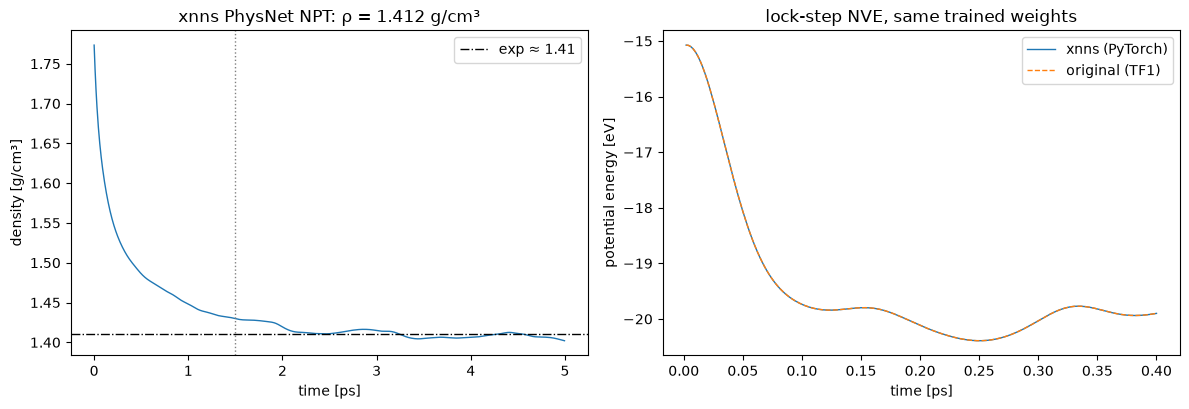

In [5]:
t_ps = np.arange(N_EQUIL + N_PROD) * (DT / u.fs) / 1000.0
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(t_ps, rho, lw=1)
ax[0].axvline(N_EQUIL * (DT / u.fs) / 1000.0, color="gray", ls=":", lw=1)
ax[0].axhline(RHO_EXP, color="k", ls="-.", lw=1, label=f"exp ≈ {RHO_EXP}")
ax[0].set_xlabel("time [ps]"); ax[0].set_ylabel("density [g/cm³]")
ax[0].set_title(f"xnn PhysNet NPT: ρ = {rho[N_EQUIL:].mean():.3f} g/cm³"); ax[0].legend()

ts = np.arange(1, 201) * 2 / 1000.0
ax[1].plot(ts, Ex, label="xnn (PyTorch)", lw=1)
ax[1].plot(ts, Et, "--", label="original (TF1)", lw=1)
ax[1].set_xlabel("time [ps]"); ax[1].set_ylabel("potential energy [eV]")
ax[1].set_title("lock-step NVE, same trained weights"); ax[1].legend()
plt.tight_layout(); plt.savefig("argon_density_md.png", dpi=120); plt.show()
sess.close()

## Summary

* The trained xnn PhysNet runs stable **NPT MD** through the standard xnn
  ASE deployment and lands near the experimental liquid-argon density.
* With the trained weights transplanted back into the **original TF1 graph**,
  a lock-step NVE run shows both force engines propagating the same
  trajectory (float32 round-off at early times, the usual chaotic divergence
  later) with comparable energy conservation.

Same conclusions, same pipeline: PhysNet joins the xnn family as a faithful,
pure-PyTorch port of a TensorFlow-era reference code, with charges, dipoles,
electrostatics and D3 dispersion intact.